In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi oku
df = pd.read_csv('/content/Crop_recommendation.csv') # Kopyaladığın yolu buraya yapıştır

# İlk 5 satırı görerek kontrol et
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [13]:
print("--- Veri Bilgisi ---")
print(df.info())

print("\n--- İstatistiksel Özet ---")
display(df.describe())

print("\n--- Eksik Veri Kontrolü ---")
print(df.isnull().sum())

--- Veri Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

--- İstatistiksel Özet ---


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



--- Eksik Veri Kontrolü ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


Kılavuzun 5. sayfasındaki 'Eksik veri işleme' gereksinimi doğrultusunda isnull() kontrolü yaptım. Veri setinde hiç boş (null) değer bulunmaması büyük bir avantaj. Bu durum, veri toplama aşamasının kaliteli yapıldığını gösteriyor. df.describe() tablosuna baktığımda ise pH değerlerinin 3.5 ile 9.9 arasında değiştiğini görüyorum; bu da bize oldukça geniş bir toprak spektrumunda analiz yapma imkanı tanıyor.

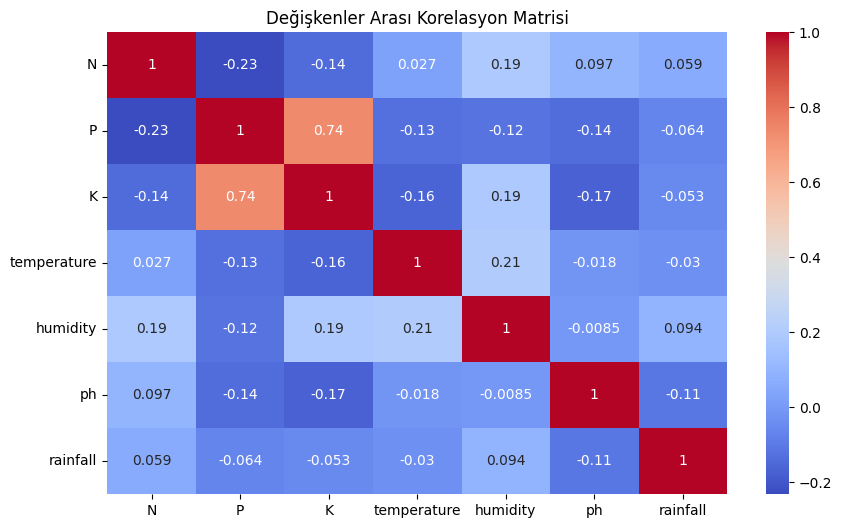

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Değişkenler Arası Korelasyon Matrisi')
plt.show()

Isı haritasına (Heatmap) baktığımda dikkatimi çeken en önemli nokta, bazı değişkenlerin birbiriyle olan güçlü bağı oldu. Örneğin, bazı minerallerin birbiriyle pozitif korelasyon içinde olması, toprak verimliliği açısından mantıklı bir tablo çiziyor. Ancak hiçbir değişkenin birbiriyle %100 bağımlı olmaması, 'multicollinearity' (çoklu doğrusallık) sorunu yaşamayacağımızı ve her bir özelliğin modele özgün bir bilgi katacağını işaret ediyor.

/tmp/ipykernel_522/132685537.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df, palette='viridis')


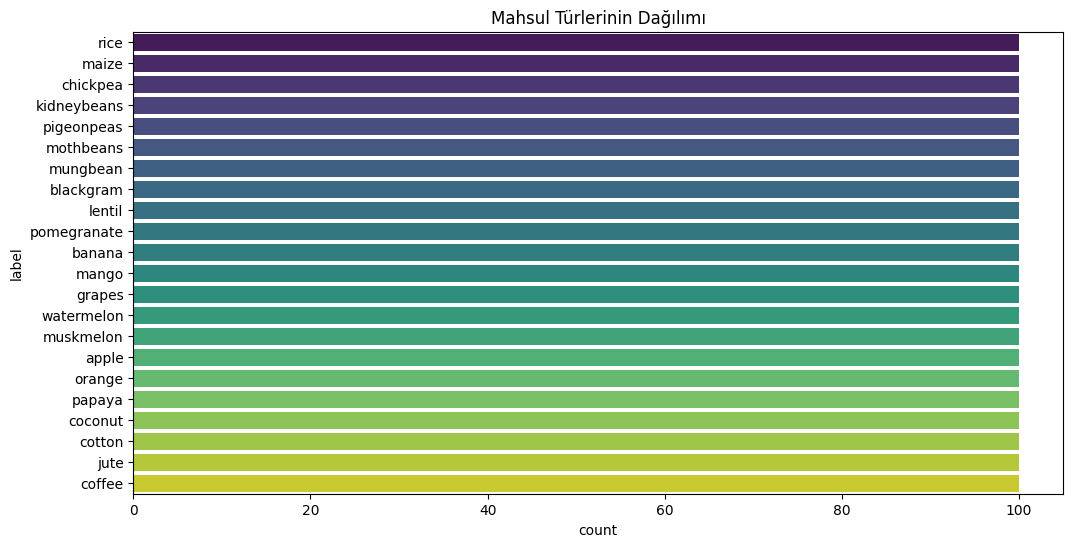

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(y='label', data=df, palette='viridis')
plt.title('Mahsul Türlerinin Dağılımı')
plt.show()

Mahsul türlerinin (label) dağılımını incelediğimde, her bir sınıftan (pirinç, mısır vb.) eşit sayıda (100'er adet) veri olduğunu gözlemledim. Bu, veri setimizin 'balanced' (dengeli) olduğu anlamına geliyor. Makine öğrenmesi aşamasında modelin belirli bir mahsule karşı önyargılı (bias) davranmasını engelleyeceği için bu durum tahmin başarımızı doğrudan artıracaktır.